# Supplementary AUPRC benchmark

**Reviewer concern addressed.** Reviewer #2 noted that AUROC is known to
be unreliable under substantial class imbalance and requested that
AUPRC, which focuses on performance on the rare positive class, be
reported as a complementary metric. The reviewer also agreed that, when
relative performance is compared against a baseline, both metrics are
valid.

**What this notebook does.** It reproduces the per-variant-type
benchmark of Figure 1 using area under the precision-recall curve
(AUPRC) in place of AUROC, and saves the results both as a supplementary
figure and as a full CSV.

**Minority-class AUPRC.** Standard AUPRC uses a single ``positive''
label. In subgroups dominated by pathogenic variants, taking
pathogenic as positive makes the chance baseline (\(\approx\) the
pathogenic fraction) almost 1, so all models pile up near 1\(\times\)
the baseline and the metric carries little information. Here we always
take the **minority** class as the PR positive class: if pathogenic
variants are the majority we flip labels (benign = positive) and negate
model scores after the usual pathogenicity sign conventions so that
higher score still means ``more likely AUPRC-positive''. The vertical
dashed line is therefore the **minority-class prevalence** (chance AUPRC
for that PR problem). Panel titles still report the **pathogenic
fraction** in the cohort (`pathogenic ...%`) plus which class is
AUPRC-positive and the chance level.

Subgroup pathogenic fractions still span more than two orders of
magnitude (from ≈1.6% for non-splice introns to ≥99% for canonical
splice variants), so **raw AUPRC values should not be compared across
subgroups**; interpret each panel against its own dashed baseline.

**Relation to the main benchmark.** AUROC remains the primary metric in
Figure 1 because it is invariant to class balance and is therefore
directly comparable across variant-type subgroups with radically
different pathogenic-variant prevalence. AUPRC is added as a
supplementary, transparency-oriented complement; it should be
interpreted within each subgroup (and relative to that subgroup's
minority baseline), not across subgroups.

The code follows the same conventions as `VEP_AUROC_figure.ipynb` for the
model list, variant-subgroup list, sign flipping, palette, and display
names. The tabular input in this notebook is `clinvar_updated.csv`, which
includes separate `Evo2_7B` and `Evo2_40B` score columns (replacing the
single `Evo2` column used in the older `dataset.csv`).


In [8]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from sklearn.metrics import average_precision_score
from tqdm import tqdm

pd.set_option("display.max_columns", 80)

DATA_PATH = "./clinvar_updated.csv"

OUT_CSV = "AUPRC_results_by_group.csv"
OUT_PDF = "AUPRC_supplementary_figure.pdf"
OUT_PNG = "AUPRC_supplementary_figure.png"
OUT_SCATTER_PDF = "AUPRC_vs_AUROC_scatter.pdf"
OUT_SCATTER_PNG = "AUPRC_vs_AUROC_scatter.png"

data = pd.read_csv(DATA_PATH, low_memory=False)



In [9]:
# --- Models, subgroups, conventions (inherited from VEP_AUROC_figure.ipynb) ---

# Protein models split into two tiers:
#   esm_models        : ESM1b, ESM1v, ESM2, VESM++ (applicable to missense, stop gain, start loss, and combinations)
#   alphafold_models  : AlphaMissense, PrimateAI-3D (applicable to missense, stop gain, and combinations ONLY — NOT start loss)
esm_models     = ["ESM1b", "ESM1v", "ESM2", "vesm_score"]
alphafold_models = ["AlphaMissense", "PrimateAI_3D"]
protein_models = esm_models + alphafold_models

tools = [
    "PhyloP", "Evo2_7B", "Evo2_40B", "AlphaGenome_quantile", "Rule_based",
    "GPN_MSA", "PhyloGPN", "gpnstar_v_llr", "DNABERT2",
    "ntv3_pre_position_llr", #"ntv3_pre_seq_pllr",
    #"ntv3_post_position_llr", "ntv3_post_seq_pllr", 
    "ntv3_post_log2fc_max",
    "ESM1b", "ESM1v", "ESM2", "vesm_score",
    "AlphaMissense", "PrimateAI_3D",
]

NO_FLIP = {
    "PhyloP", "DNABERT2",
    "AlphaMissense", "PrimateAI_3D", "AlphaGenome_quantile", "Rule_based",
}

# Index boundaries (0-based):
#   DNA-only  : tools[:13]  (indices 0–12, up to ntv3_post_log2fc_max)
#   + ESM     : tools[:17]  (indices 0–16, adds ESM1b/ESM1v/ESM2/vesm_score)
#   + all PLM : tools[:]    (indices 0–19, adds AlphaMissense/PrimateAI_3D)
_DNA   = tools[:11]
_ESM   = tools[:15]
_ALL   = tools[:]

subgroups = [
    "group: missense",                      # 0 — all models
    "group: missense + 3'UTR",               # 1 — all models
    "group: missense + intron (non-splice)", # 2 — all models
    "group: stop gain",                     # 3 — all models
    "group: start loss",                    # 4 — DNA + ESM only (no AlphaMissense/PrimateAI-3D)
    "group: noncoding",                     # 5 — DNA only
    "group: stop loss",                     # 6 — DNA only
    "group: synonymous",                    # 7 — DNA only
    "group: 5'UTR",                          # 8 — DNA only
    "group: 3'UTR",                          # 9 — DNA only
    "group: 3'UTR + RNA gene",               # 10 — DNA only
    "group: splice",                        # 11 — DNA only
    "group: intron (non-splice)",            # 12 — DNA only
    "group: RNA gene",                      # 13 — DNA only
]

TOOLS_PER_SUBGROUP = {}
for i, sg in enumerate(subgroups):
    if i in (0, 1, 2, 3):
        TOOLS_PER_SUBGROUP[sg] = _ALL       # missense, stop gain, combinations — all models
    elif i == 4:
        TOOLS_PER_SUBGROUP[sg] = _ESM       # start loss — DNA + ESM (no AlphaMissense/PrimateAI-3D)
    else:
        TOOLS_PER_SUBGROUP[sg] = _DNA       # noncoding subgroups — DNA only

rename_dict = {
    "Evo2_7B":               "Evo2 7B",
    "Evo2_40B":              "Evo2 40B",
    "DNABERT2":              "DNABERT2",
    "PhyloP":                "PhyloP",
    "AlphaGenome_quantile":  "AlphaGenome",
    "GPN_MSA":               "GPN-MSA",
    "PhyloGPN":              "PhyloGPN",
    "gpnstar_v_llr":         "GPN-Star",
    "ntv3_pre_position_llr": "NTv3-pre",
    "ntv3_pre_seq_pllr":     "NTv3-pre PLLR",
    "ntv3_post_position_llr":"NTv3-post LLR",
    "ntv3_post_seq_pllr":    "NTv3-post PLLR",
    "ntv3_post_log2fc_max":  "NTv3-post",
    "ESM1b":                 "ESM1b",
    "ESM1v":                 "ESM1v",
    "ESM2":                  "ESM2",
    "vesm_score":            "VESM++",
    "PrimateAI_3D":          "PrimateAI-3D",
    "AlphaMissense":         "AlphaMissense",
    "Rule_based":            "Rule-based",
}
palette = {
    "Evo2 7B":          "#e56b6f",
    "Evo2 40B":         "#c93735",
    "DNABERT2":         "#1b78b2",
    "NTv3-pre":     "#6baed6",
    "NTv3-pre PLLR":    "#4292c6",
    "NTv3-post LLR":    "#2171b5",
    "NTv3-post PLLR":   "#084594",
    "NTv3-post": "#54278f",
    "GPN-Star":         "#20b2aa",
    "PhyloP":           "#808080",
    "GPN-MSA":          "#859ed7",
    "PhyloGPN":         "#f47f1e",
    "AlphaGenome":      "#a2d94d",
    "ESM1b":            "#2da248",
    "ESM1v":            "#8f69c5",
    "ESM2":             "#22bdd2",
    "VESM++":           "#e377c2",
    "PrimateAI-3D":     "#d26101",
    "AlphaMissense":    "#333a8c",
    "Rule-based":       "#b0b0b0",
}
dashed_models = ["ESM1b", "ESM1v", "ESM2", "AlphaMissense", "PrimateAI-3D", "VESM++"]
display_map = {
    "group: noncoding":                      "Noncoding",
    "group: intron (non-splice)":            "Intron (Non-splice)",
    "group: splice":                         "Splice",
    "group: 5'UTR":                          "5' UTR",
    "group: 3'UTR":                          "3' UTR",
    "group: 3'UTR + RNA gene":               "3' UTR + RNA gene",
    "group: RNA gene":                       "RNA gene",
    "group: synonymous":                     "Synonymous",
    "group: start loss":                     "Start loss",
    "group: stop loss":                      "Stop loss",
    "group: missense":                       "Missense",
    "group: missense + intron (non-splice)": "Missense & Intron (Non-splice)",
    "group: missense + 3'UTR":              "Missense & 3'UTR",
    "group: stop gain":                      "Stop gain",
}
ordered_display_names = [
    "All variants", "Noncoding", "Intron (Non-splice)", "Splice", "3' UTR", "5' UTR",
    "RNA gene", "Synonymous", "Stop loss", "Start loss",
    "Missense", "Missense & Intron (Non-splice)", "Missense & 3'UTR", "Stop gain"
]

# Convenience groupings (display names) for downstream use
DNA_MODELS = [
    "PhyloP", "AlphaGenome", "Evo2 7B", "Evo2 40B", "GPN-MSA",
    "PhyloGPN", "GPN-Star", "NTv3-pre LLR", "NTv3-pre PLLR",
    "NTv3-post LLR", "NTv3-post PLLR", "NTv3-post log2FC", "DNABERT2",
]
ESM_MODELS     = ["ESM1b", "ESM1v", "ESM2", "VESM++"]
PROTEIN_MODELS = ESM_MODELS + ["AlphaMissense", "PrimateAI-3D"]


In [10]:
# # --- Models, subgroups, conventions (inherited from VEP_AUROC_figure.ipynb) ---

# tools = [
#     "PhyloP", "Evo2_7B", "Evo2_40B", "AlphaGenome_quantile", "Rule_based",
#     "GPN_MSA", "PhyloGPN", "Nucleotide_Transformer", "DNABERT2",
#     "ESM1b", "ESM1v", "ESM2", "AlphaMissense", "PrimateAI_3D",
# ]

# # Models whose raw score already has higher = more pathogenic for subgroup analysis.
# NO_FLIP = {
#     "PhyloP", "DNABERT2", "Nucleotide_Transformer",
#     "AlphaMissense", "PrimateAI_3D", "AlphaGenome_quantile", "Rule_based",
# }

# subgroups = [
#     "group: missense",
#     "group: missense + 3'UTR",
#     "group: missense + intron (non-splice)",
#     "group: stop gain",
#     "group: start loss",
#     "group: noncoding",
#     "group: stop loss",
#     "group: synonymous",
#     "group: 5'UTR",
#     "group: 3'UTR",
#     "group: 3'UTR + RNA gene",
#     "group: splice",
#     "group: intron (non-splice)",
#     "group: RNA gene",
# ]

# TOOLS_PER_SUBGROUP = {}
# for i, sg in enumerate(subgroups):
#     if i in (0, 1, 2):
#         TOOLS_PER_SUBGROUP[sg] = tools[:]
#     elif i == 3:
#         TOOLS_PER_SUBGROUP[sg] = tools[:13]
#     elif i == 4:
#         TOOLS_PER_SUBGROUP[sg] = tools[:12]
#     else:
#         TOOLS_PER_SUBGROUP[sg] = tools[:9]

# rename_dict = {
#     "Evo2_7B": "Evo2 7B", "Evo2_40B": "Evo2 40B", "DNABERT2": "DNABERT2",
#     "Nucleotide_Transformer": "Nucleotide Transformer",
#     "PhyloP": "PhyloP", "AlphaGenome_quantile": "AlphaGenome",
#     "GPN_MSA": "GPN-MSA", "PhyloGPN": "PhyloGPN",
#     "ESM1b": "ESM1b", "ESM1v": "ESM1v", "ESM2": "ESM2",
#     "PrimateAI_3D": "PrimateAI-3D", "AlphaMissense": "AlphaMissense",
#     "Rule_based": "Rule-based",
# }
# palette = {
#     "Evo2 7B": "#e56b6f", "Evo2 40B": "#c93735", "DNABERT2": "#1b78b2",
#     "Nucleotide Transformer": "#9368ab", "PhyloP": "#808080",
#     "GPN-MSA": "#859ed7", "PhyloGPN": "#f47f1e",
#     "AlphaGenome": "#a2d94d", "ESM1b": "#2da248",
#     "ESM1v": "#8f69c5", "ESM2": "#22bdd2",
#     "PrimateAI-3D": "#d26101", "AlphaMissense": "#333a8c",
#     "Rule-based": "#b0b0b0",
# }
# dashed_models = {"ESM1b", "ESM1v", "ESM2", "AlphaMissense", "PrimateAI-3D"}

# display_map = {
#     "Overall": "All variants", "group: noncoding": "Noncoding",
#     "group: intron (non-splice)": "Intron (Non-splice)",
#     "group: splice": "Splice", "group: 5'UTR": "5' UTR",
#     "group: 3'UTR": "3' UTR", "group: RNA gene": "RNA gene",
#     "group: synonymous": "Synonymous", "group: start loss": "Start loss",
#     "group: stop loss": "Stop loss", "group: missense": "Missense",
#     "group: missense + intron (non-splice)": "Missense & Intron (Non-splice)",
#     "group: missense + 3'UTR": "Missense & 3'UTR",
#     "group: stop gain": "Stop gain",
#     "group: 3'UTR + RNA gene": "3' UTR + RNA gene",
# }
# ordered_display_names = [
#     "All variants", "Noncoding", "Intron (Non-splice)", "Splice",
#     "3' UTR", "5' UTR", "RNA gene",
#     "Synonymous", "Stop loss", "Start loss",
#     "Missense", "Missense & Intron (Non-splice)", "Missense & 3'UTR",
#     "Stop gain",
# ]



In [11]:
# --- Bootstrap AUPRC helper ---
# AUPRC is computed on the *minority* class (pathogenic or benign): in groups
# dominated by pathogenic labels we flip labels so y=1 identifies the rare
# class, and negate scores so "higher = more likely positive" for PR.
# Chance-level AUPRC equals the prevalence of that AUPRC positive class.

MIN_PER_CLASS = 5


def auprc_chance_level_and_positive_class(y_pathogenic):
    """Baseline (random ranker) AUPRC and name of the AUPRC positive class."""
    y_pathogenic = np.asarray(y_pathogenic).astype(int)
    n = len(y_pathogenic)
    if n == 0:
        return np.nan, ""
    n_pos = int(y_pathogenic.sum())
    n_neg = n - n_pos
    if n_pos > n_neg:
        return float(n_neg) / n, "benign"
    return float(n_pos) / n, "pathogenic"


def prepare_auprc_inputs(y_pathogenic, scores_pathogenic_high):
    """Return (y_auprc, s_auprc, baseline, positive_class) for average_precision_score."""
    y_pathogenic = np.asarray(y_pathogenic).astype(int)
    scores_pathogenic_high = np.asarray(scores_pathogenic_high).astype(float)
    n = len(y_pathogenic)
    if n == 0:
        return np.array([]), np.array([]), np.nan, ""
    n_pos = int(y_pathogenic.sum())
    n_neg = n - n_pos
    if n_pos > n_neg:
        y_ap = 1 - y_pathogenic
        s_ap = -scores_pathogenic_high
        baseline = float(n_neg) / n
        positive_class = "benign"
    else:
        y_ap = y_pathogenic
        s_ap = scores_pathogenic_high
        baseline = float(n_pos) / n
        positive_class = "pathogenic"
    return y_ap, s_ap, baseline, positive_class


def bootstrap_auprc_ci(y, s, n_boot=200, seed=42):
    y = np.asarray(y).astype(int)
    s = np.asarray(s).astype(float)
    n = len(y)
    if n == 0 or len(np.unique(y)) < 2:
        return np.nan, np.nan, np.nan
    ap_hat = average_precision_score(y, s)
    rng = np.random.default_rng(seed)
    aps = []
    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)
        yb = y[idx]
        if len(np.unique(yb)) < 2:
            continue
        aps.append(average_precision_score(yb, s[idx]))
    if len(aps) < max(30, 0.5 * n_boot):
        return float(ap_hat), np.nan, np.nan
    lo, hi = np.percentile(aps, [2.5, 97.5])
    return float(ap_hat), float(lo), float(hi)



In [12]:
# --- Compute AUPRC and prevalence per (subgroup, model) ---
# `prevalence` = chance-level AUPRC (minority-class prevalence).
# `prevalence_pathogenic` = fraction ClinVar-pathogenic (1) in the subgroup.

rows = []

# Overall (all variants): DNA-only tools (indices 0–12); protein models not included in the overall panel.
overall_tools = _DNA
overall_sub = data[data[overall_tools[:7]].notna().all(axis=1)].copy()
y_overall = overall_sub["ClinVar_label"].astype(int).values
prev_path_overall = float(y_overall.mean()) if len(y_overall) else np.nan
baseline_overall, pos_cls_overall = auprc_chance_level_and_positive_class(y_overall)

for tool in tools:
    tool_disp = rename_dict[tool]
    if tool in overall_tools:
        scores = overall_sub[tool].values.astype(float)
        if tool not in NO_FLIP:
            scores = -scores
        y_ap, s_ap, _, _ = prepare_auprc_inputs(y_overall, scores)
        ap, lo, hi = bootstrap_auprc_ci(y_ap, s_ap)
    else:
                ap, lo, hi = (np.nan, np.nan, np.nan)
    rows.append({
        "subgroup_raw": "Overall",
        "subgroup_display": "All variants",
        "model": tool_disp,
        "N": len(overall_sub), "N_pos": int(y_overall.sum()),
        "N_neg": int(len(overall_sub) - y_overall.sum()),
        "prevalence_pathogenic": prev_path_overall,
        "prevalence": baseline_overall,
        "auprc_positive_class": pos_cls_overall,
        "AUPRC": ap, "CI_low": lo, "CI_high": hi,
        "AUPRC_minus_baseline": (ap - baseline_overall) if not np.isnan(ap) else np.nan,
    })

for sg, sg_tools in tqdm(list(TOOLS_PER_SUBGROUP.items()), desc="Subgroups"):
    sg_df = data[data[sg] == 1]
    sg_df = sg_df[sg_df[sg_tools].notna().all(axis=1)]
    y = sg_df["ClinVar_label"].astype(int).values
    n = len(sg_df)
    npos = int(y.sum()); nneg = n - npos
    prev_path = float(npos / n) if n else np.nan
    baseline_sg, pos_cls_sg = auprc_chance_level_and_positive_class(y)
    disp = display_map.get(sg, sg)
    for tool in tools:
        tool_disp = rename_dict[tool]
        if tool not in sg_tools:
            ap, lo, hi = (np.nan, np.nan, np.nan)
        elif npos < MIN_PER_CLASS or nneg < MIN_PER_CLASS:
            ap, lo, hi = (np.nan, np.nan, np.nan)
        else:
            scores = sg_df[tool].values.astype(float)
            if tool not in NO_FLIP:
                scores = -scores
            y_ap, s_ap, _, _ = prepare_auprc_inputs(y, scores)
            ap, lo, hi = bootstrap_auprc_ci(y_ap, s_ap)
        rows.append({
            "subgroup_raw": sg, "subgroup_display": disp, "model": tool_disp,
            "N": n, "N_pos": npos, "N_neg": nneg,
            "prevalence_pathogenic": prev_path,
            "prevalence": baseline_sg,
            "auprc_positive_class": pos_cls_sg,
            "AUPRC": ap, "CI_low": lo, "CI_high": hi,
            "AUPRC_minus_baseline": (ap - baseline_sg) if not np.isnan(ap) else np.nan,
        })

auprc_df = pd.DataFrame(rows)
auprc_df.to_csv(OUT_CSV, index=False)
print(f"Saved full AUPRC table: {OUT_CSV}  ({len(auprc_df):,} rows)")



Subgroups: 100%|██████████| 14/14 [01:27<00:00,  6.26s/it]

Saved full AUPRC table: AUPRC_results_by_group.csv  (255 rows)


In [13]:
auprc_df[auprc_df.subgroup_raw=='group: start loss']

,subgroup_raw,subgroup_display,model,N,N_pos,N_neg,prevalence_pathogenic,prevalence,auprc_positive_class,AUPRC,CI_low,CI_high,AUPRC_minus_baseline
85,group: start loss,Start loss,PhyloP,788,770,18,0.977157,0.022843,benign,0.051079,0.026176,0.105628,0.028236
86,group: start loss,Start loss,Evo2 7B,788,770,18,0.977157,0.022843,benign,0.076452,0.037355,0.151832,0.053609
87,group: start loss,Start loss,Evo2 40B,788,770,18,0.977157,0.022843,benign,0.186969,0.082491,0.401474,0.164127
88,group: start loss,Start loss,AlphaGenome,788,770,18,0.977157,0.022843,benign,0.059725,0.017922,0.211840,0.036883
89,group: start loss,Start loss,Rule-based,788,770,18,0.977157,0.022843,benign,0.022843,0.012690,0.033027,0.000000
90,group: start loss,Start loss,GPN-MSA,788,770,18,0.977157,0.022843,benign,0.072732,0.035531,0.175954,0.049889
91,group: start loss,Start loss,PhyloGPN,788,770,18,0.977157,0.022843,benign,0.036223,0.017426,0.086197,0.013381
92,group: start loss,Start loss,GPN-Star,788,770,18,0.977157,0.022843,benign,0.079235,0.039627,0.170560,0.056392
93,group: start loss,Start loss,DNABERT2,788,770,18,0.977157,0.022843,benign,0.020114,0.011645,0.035712,-0.002729
94,group: start loss,Start loss,NTv3-pre,788,770,18,0.977157,0.022843,benign,0.040664,0.020167,0.100155,0.017821


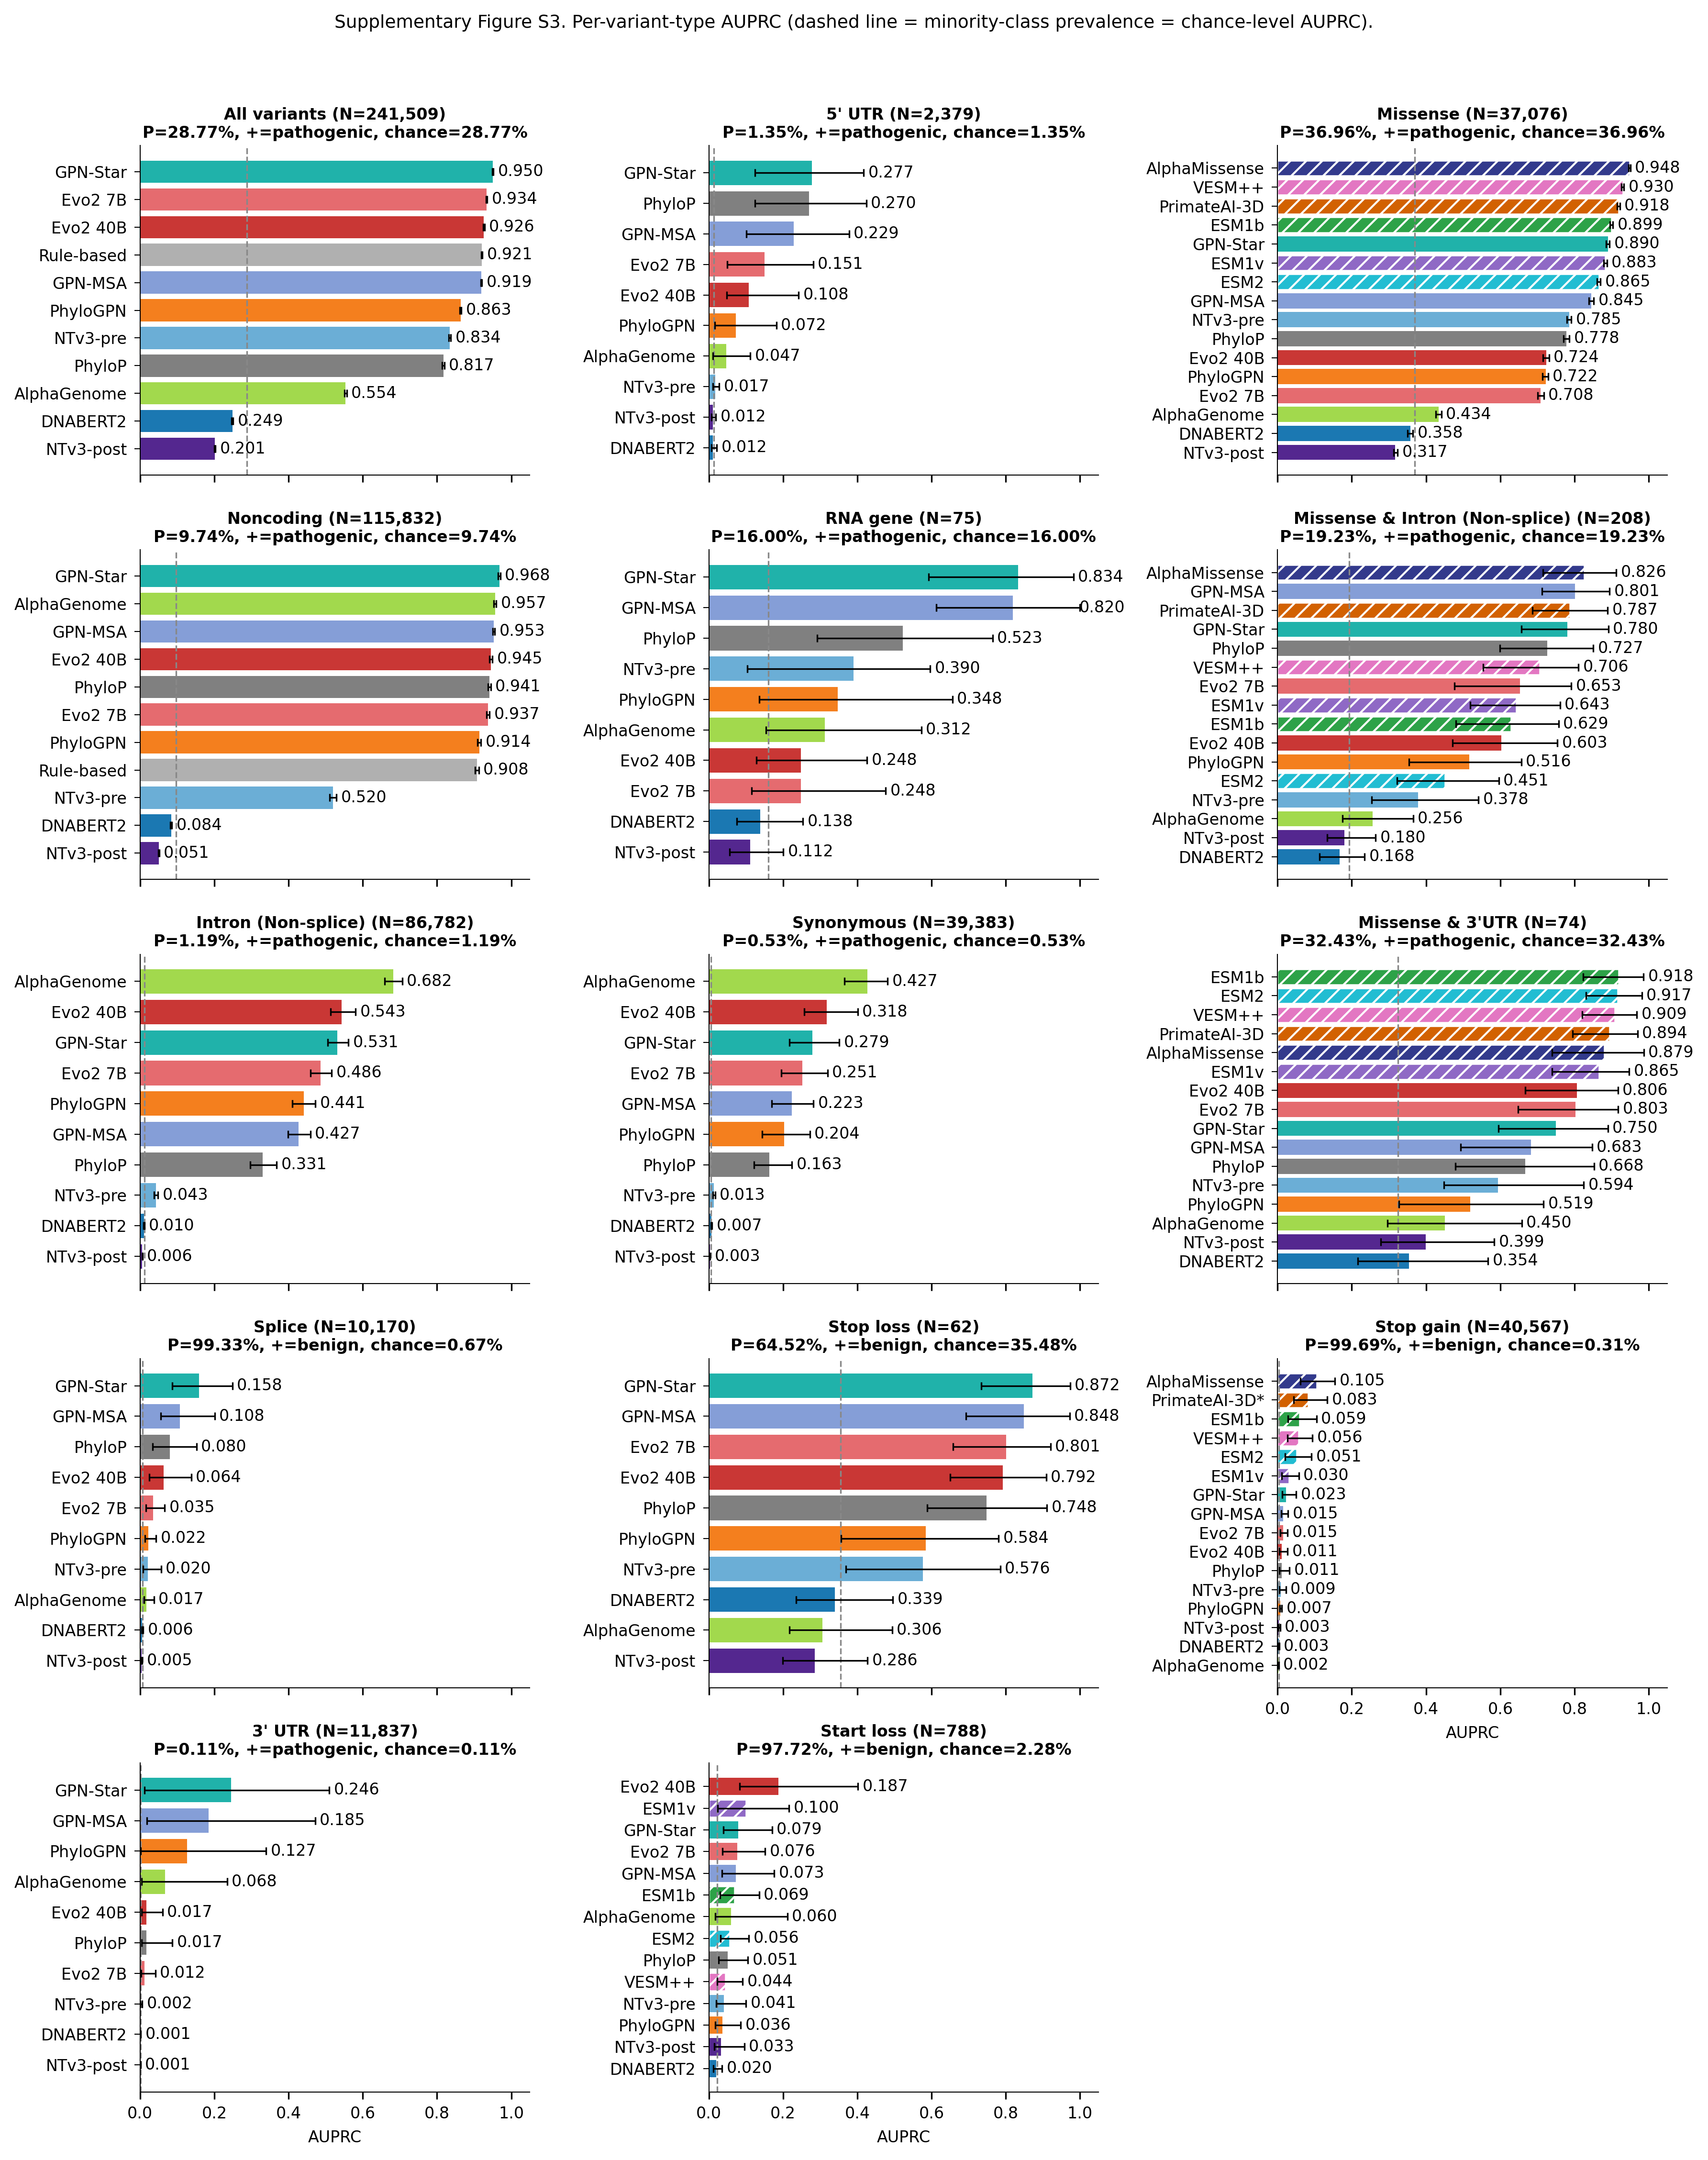

In [14]:
# --- Supplementary AUPRC figure (mirrors Figure 1 layout) ---

FONT_SIZE = 8
FONT_NAME = "DejaVu Sans"

def draw_panel(ax, disp_name, show_xlabel=False, show_numbers=False):
    panel = auprc_df[(auprc_df["subgroup_display"] == disp_name) & auprc_df["AUPRC"].notna()].copy()
    if disp_name not in ("All variants", "Noncoding"):
        panel = panel[panel["model"] != "Rule-based"]
    panel = panel.sort_values("AUPRC", ascending=True)

    n = int(panel["N"].iloc[0]) if len(panel) else 0
    prev_base = float(panel["prevalence"].iloc[0]) if len(panel) else np.nan
    prev_path = float(panel["prevalence_pathogenic"].iloc[0]) if len(panel) else np.nan
    ap_pos = str(panel["auprc_positive_class"].iloc[0]) if len(panel) else ""

    for _, r in panel.iterrows():
        color = palette.get(r["model"], "#444444")
        hatch = "///" if r["model"] in dashed_models else None
        label = r["model"]
        if disp_name == "Stop gain" and r["model"] == "PrimateAI-3D":
            label = "PrimateAI-3D*"
        ax.barh(label, r["AUPRC"], color=color, hatch=hatch,
                edgecolor="white" if hatch else None, linewidth=0.6)

        lo, hi = r["CI_low"], r["CI_high"]
        if pd.notna(lo) and pd.notna(hi) and hi >= lo:
            ax.errorbar(r["AUPRC"], label,
                        xerr=[[r["AUPRC"] - lo], [hi - r["AUPRC"]]],
                        fmt="none", ecolor="black",
                        elinewidth=0.8, capsize=2, capthick=0.8, zorder=10)
            x_anchor = max(r["AUPRC"], hi)
        else:
            x_anchor = r["AUPRC"]
        x_text = min(x_anchor + 0.012, 1.0 - 0.002)
        ax.text(x_text, label, f"{r['AUPRC']:.3f}",
                va="center", ha="left",
                fontsize=FONT_SIZE, fontname=FONT_NAME)

    if not np.isnan(prev_base):
        ax.axvline(prev_base, color="#888888", lw=0.8, ls="--")

    ax.set_xlim(0, 1.05)
    ax.xaxis.set_major_locator(ticker.MultipleLocator(0.2))
    xticks = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
    ax.set_xticks(xticks)
    if show_numbers:
        ax.set_xticklabels([f"{t:.1f}" for t in xticks],
                           fontsize=FONT_SIZE, fontname=FONT_NAME)
        ax.tick_params(axis="x", labelbottom=True)
    else:
        ax.tick_params(axis="x", labelbottom=False)
    if show_xlabel:
        ax.set_xlabel("AUPRC", fontsize=FONT_SIZE, fontname=FONT_NAME)

    ax.tick_params(axis="y", which="major", left=True, labelleft=True,
                   width=0.5, length=3.0)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["bottom"].set_linewidth(0.5)
    ax.spines["left"].set_linewidth(0.5)
    ax.tick_params(labelsize=FONT_SIZE)
    for lab in ax.get_yticklabels():
        lab.set_fontname(FONT_NAME)

    path_str = f"{100 * prev_path:.2f}%" if not np.isnan(prev_path) else "NA"
    base_str = f"{100 * prev_base:.2f}%" if not np.isnan(prev_base) else "NA"
    ax.set_title(
        f"{disp_name} (N={n:,})\n"
        f"P={path_str}, +={ap_pos}, chance={base_str}",
        fontsize=FONT_SIZE,
        fontname=FONT_NAME,
        fontweight="bold",
        pad=4,
    )

fig, axes = plt.subplots(nrows=5, ncols=3, figsize=(12, 15), dpi=300)
axes = axes.T.flatten()
for i, disp_name in enumerate(ordered_display_names):
    col = i // 5
    row = i % 5
    show_xlabel = (col == 0 and row == 4) or (col == 1 and row == 4) or (col == 2 and row == 3)
    draw_panel(axes[i], disp_name,
               show_xlabel=show_xlabel, show_numbers=show_xlabel)
axes[-1].axis("off")

fig.suptitle(
    "Supplementary Figure S3. Per-variant-type AUPRC (dashed line = minority-class prevalence = chance-level AUPRC).",
    fontsize=FONT_SIZE + 1, fontname=FONT_NAME, y=1.0,
)
fig.tight_layout(rect=[0, 0, 1, 0.985])
fig.savefig('FigureS4.svg', format="svg", bbox_inches="tight")

# fig.savefig(OUT_PDF, format="pdf", bbox_inches="tight")
# fig.savefig(OUT_PNG, format="png", dpi=300, bbox_inches="tight")
plt.show()



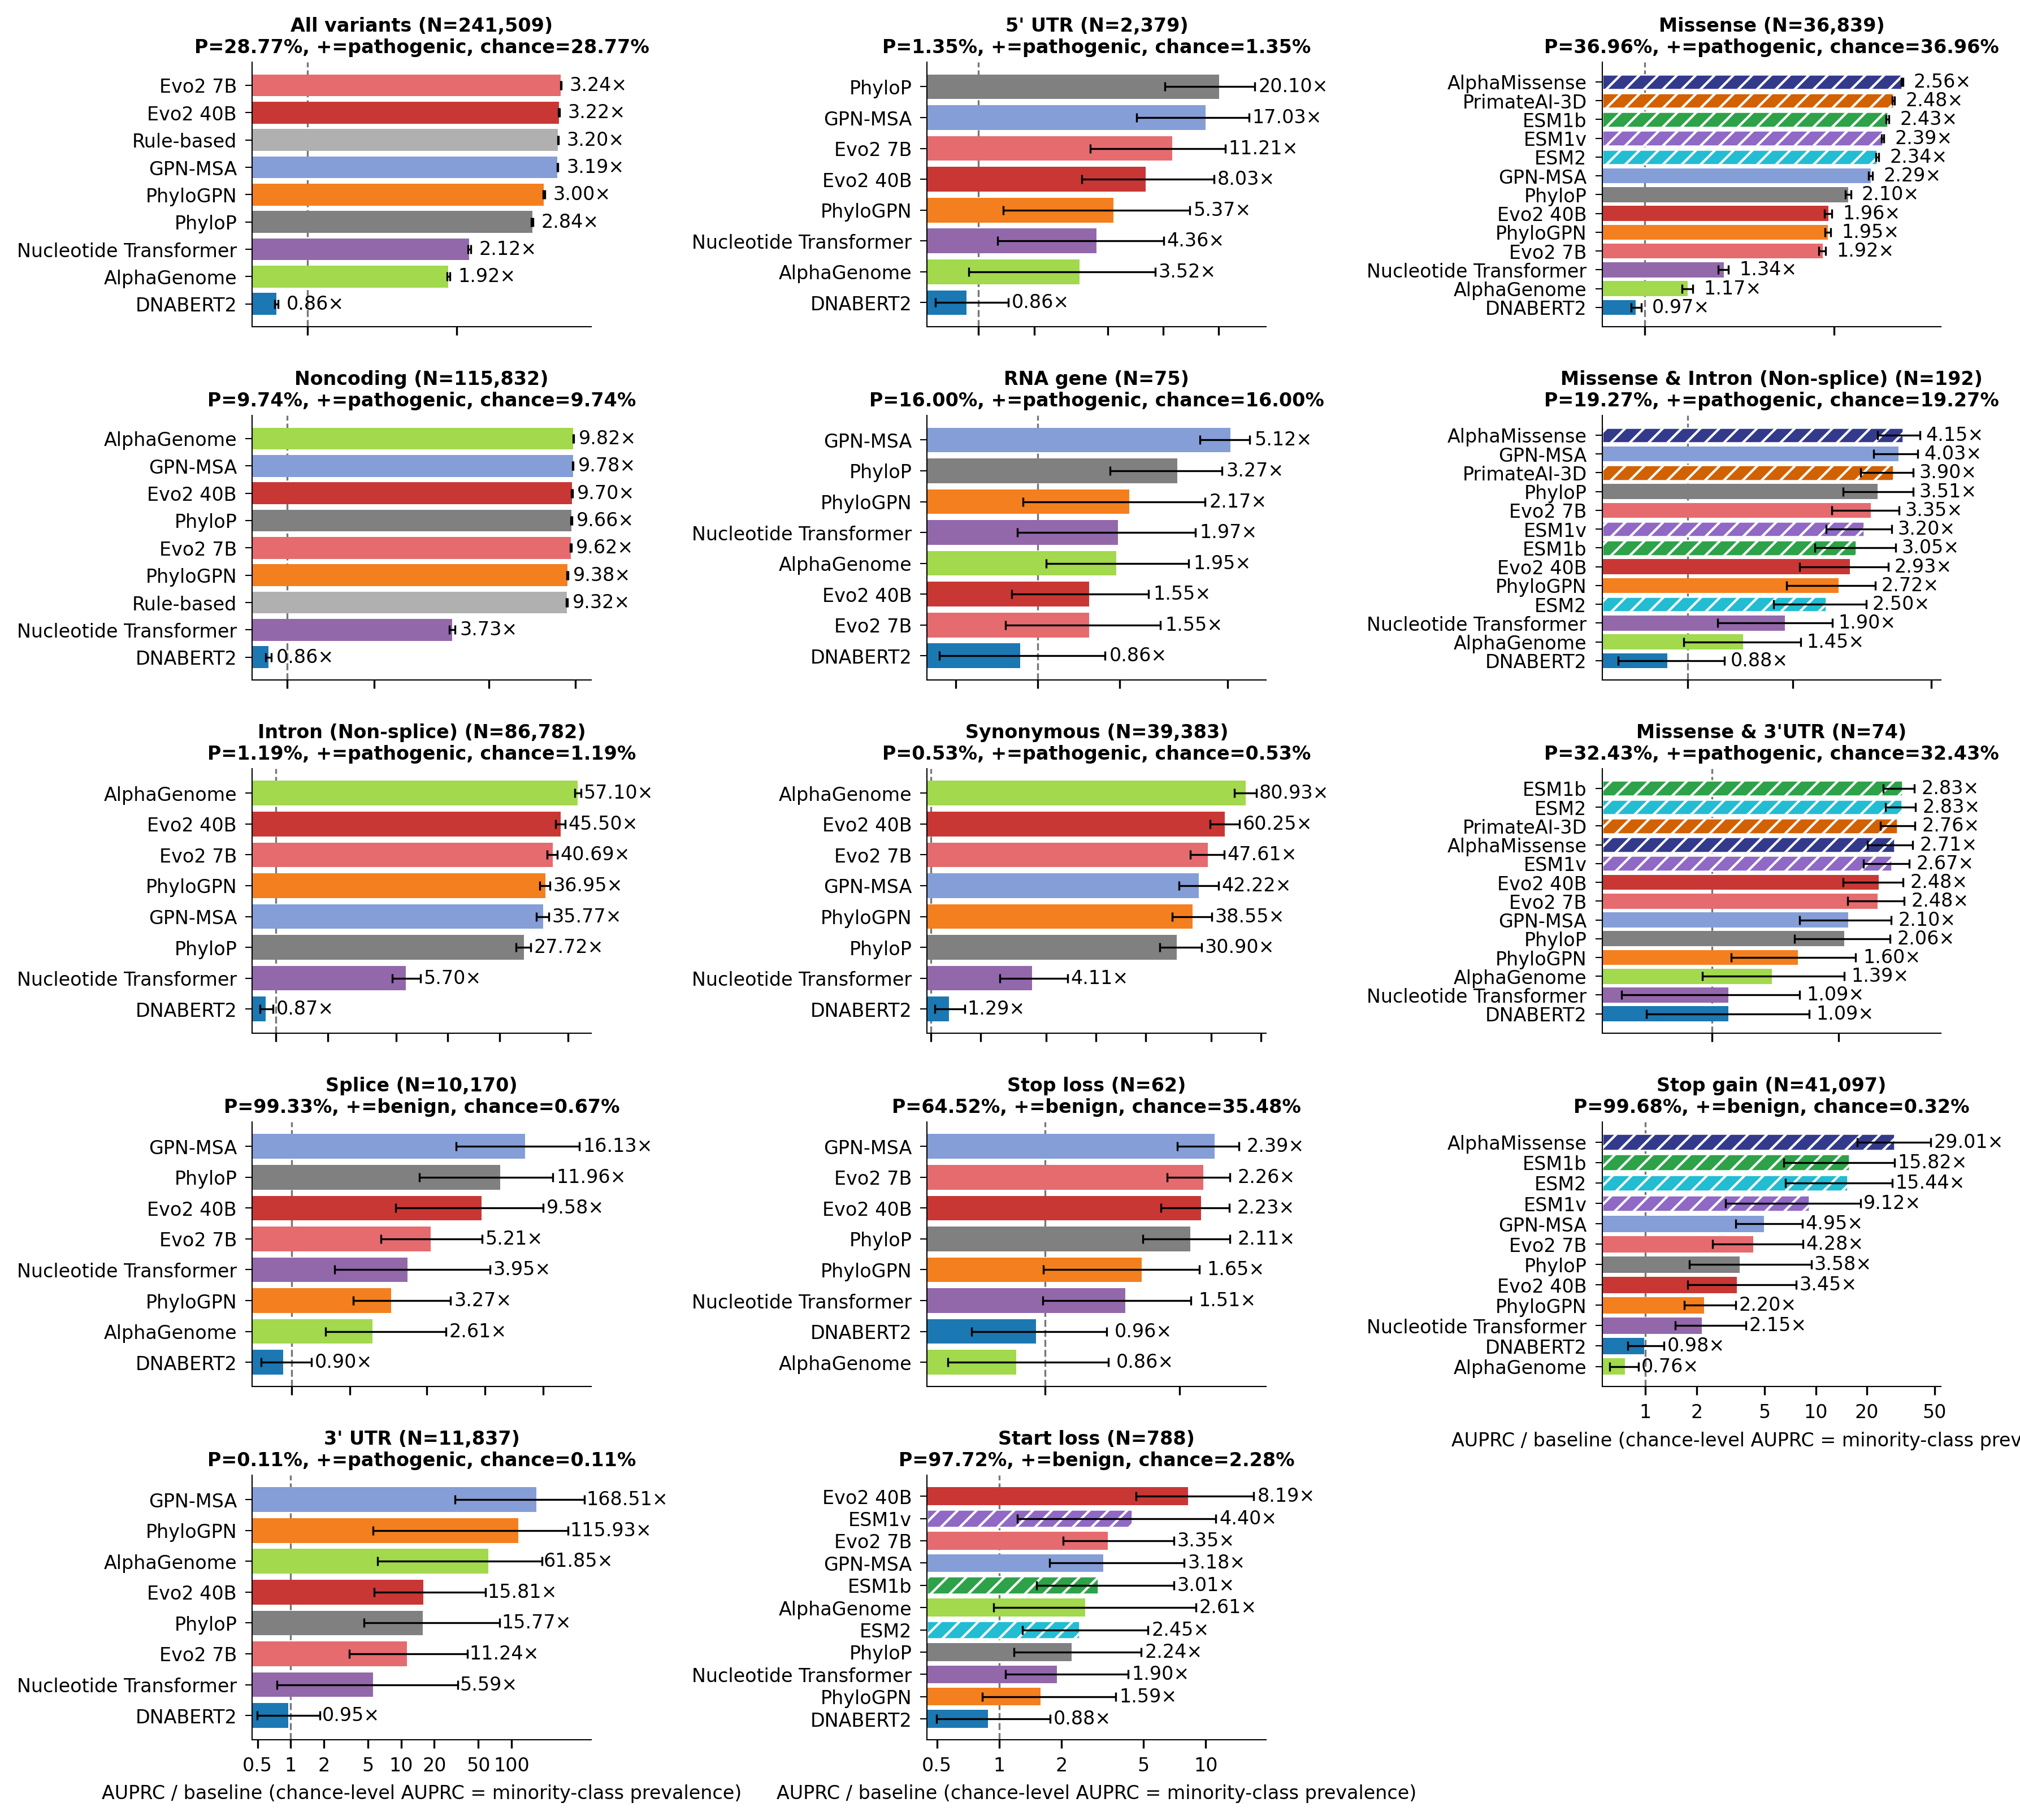

Saved: AUPRC_over_baseline_figure.pdf and AUPRC_over_baseline_figure.png
Within-subgroup Spearman(AUPRC, AUPRC/baseline) -- should all be 1.0:
                      subgroup  spearman  n_models
                        3' UTR       1.0         9
                        5' UTR       1.0         9
                  All variants       1.0         9
           Intron (Non-splice)       1.0         9
                      Missense       1.0        14
              Missense & 3'UTR       1.0        14
Missense & Intron (Non-splice)       1.0        14
                     Noncoding       1.0         9
                      RNA gene       1.0         9
                        Splice       1.0         9
                    Start loss       1.0        12
                     Stop gain       1.0        13
                     Stop loss       1.0         9
                    Synonymous       1.0         9


In [10]:
# --- Supplementary AUPRC figure: % of baseline (AUPRC / prevalence) ---
# Same panel layout as the AUPRC figure above, but the x-axis is the *ratio*
# of each model's AUPRC to the chance-level AUPRC for that subgroup
# (minority-class prevalence), so:
#   - 1.0 (or 100%) = exactly as good as a random ranker
#   - > 1.0          = better than baseline
#   - < 1.0          = worse than baseline (rare but possible after sign-flip)
# The point of this view is to check whether the per-subgroup ranking
# obtained from "fold over baseline" is consistent with the AUROC ranking
# in the main manuscript.

OUT_RATIO_PDF = "AUPRC_over_baseline_figure.pdf"
OUT_RATIO_PNG = "AUPRC_over_baseline_figure.png"

# Add ratio + CI-ratio columns (idempotent if the cell is re-run)
auprc_df["AUPRC_over_baseline"]  = auprc_df["AUPRC"]   / auprc_df["prevalence"]
auprc_df["CI_low_ratio"]         = auprc_df["CI_low"]  / auprc_df["prevalence"]
auprc_df["CI_high_ratio"]        = auprc_df["CI_high"] / auprc_df["prevalence"]
auprc_df.to_csv(OUT_CSV, index=False)


def draw_ratio_panel(ax, disp_name, show_xlabel=False, show_numbers=False):
    panel = auprc_df[
        (auprc_df["subgroup_display"] == disp_name)
        & auprc_df["AUPRC_over_baseline"].notna()
    ].copy()
    if disp_name not in ("All variants", "Noncoding"):
        panel = panel[panel["model"] != "Rule-based"]
    panel = panel.sort_values("AUPRC_over_baseline", ascending=True)

    n = int(panel["N"].iloc[0]) if len(panel) else 0
    prev_base = float(panel["prevalence"].iloc[0]) if len(panel) else np.nan
    prev_path = float(panel["prevalence_pathogenic"].iloc[0]) if len(panel) else np.nan
    ap_pos = str(panel["auprc_positive_class"].iloc[0]) if len(panel) else ""

    # Per-panel x-range (log scale).
    vals = pd.concat([panel["AUPRC_over_baseline"],
                      panel["CI_low_ratio"], panel["CI_high_ratio"]]).dropna()
    if len(vals):
        x_lo = max(min(vals.min() * 0.9, 0.95), 1e-2)
        x_hi = max(vals.max() * 1.15, 1.05)
    else:
        x_lo, x_hi = 0.9, 1.1

    for _, r in panel.iterrows():
        color = palette.get(r["model"], "#444444")
        hatch = "///" if r["model"] in dashed_models else None
        label = r["model"]
        if disp_name == "Stop gain" and r["model"] == "PrimateAI-3D":
            label = "PrimateAI-3D*"
        ratio = float(r["AUPRC_over_baseline"])

        # Bar from the panel's left bound (visually equivalent on log scale).
        ax.barh(label, max(ratio - x_lo, 0.0), left=x_lo,
                color=color, hatch=hatch,
                edgecolor="white" if hatch else None, linewidth=0.6)

        lo, hi = r["CI_low_ratio"], r["CI_high_ratio"]
        if pd.notna(lo) and pd.notna(hi) and hi >= lo:
            ax.errorbar(ratio, label,
                        xerr=[[max(ratio - lo, 0)], [max(hi - ratio, 0)]],
                        fmt="none", ecolor="black",
                        elinewidth=0.8, capsize=2, capthick=0.8, zorder=10)
            x_anchor = max(ratio, hi)
        else:
            x_anchor = ratio
        # Numeric label after the right edge (kept inside xlim).
        x_text = min(x_anchor * 1.04, x_hi * 0.97)
        ax.text(x_text, label, f"{ratio:.2f}\u00d7",
                va="center", ha="left",
                fontsize=FONT_SIZE, fontname=FONT_NAME)

    # Reference line at x=1 (= baseline).
    ax.axvline(1.0, color="#777777", lw=0.8, ls="--", zorder=0)

    ax.set_xscale("log")
    ax.set_xlim(x_lo, x_hi)

    # Build clean log-tick set within the visible range.
    candidate_ticks = np.array([0.1, 0.2, 0.5, 1, 2, 5, 10, 20, 50, 100])
    ticks = candidate_ticks[(candidate_ticks >= x_lo) & (candidate_ticks <= x_hi)]
    if 1.0 not in ticks:
        ticks = np.sort(np.append(ticks, 1.0))
    ax.set_xticks(ticks)
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(
        lambda v, _: ("1" if abs(v - 1) < 1e-9
                      else (f"{v:g}"))
    ))
    ax.minorticks_off()

    if show_numbers:
        ax.tick_params(axis="x", labelbottom=True)
        for tick in ax.get_xticklabels():
            tick.set_fontsize(FONT_SIZE)
            tick.set_fontname(FONT_NAME)
    else:
        ax.tick_params(axis="x", labelbottom=False)
    if show_xlabel:
        ax.set_xlabel(
            "AUPRC / baseline (chance-level AUPRC = minority-class prevalence)",
            fontsize=FONT_SIZE, fontname=FONT_NAME,
        )

    ax.tick_params(axis="y", which="major", left=True, labelleft=True,
                   width=0.5, length=3.0)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["bottom"].set_linewidth(0.5)
    ax.spines["left"].set_linewidth(0.5)
    ax.tick_params(labelsize=FONT_SIZE)
    for lab in ax.get_yticklabels():
        lab.set_fontname(FONT_NAME)

    path_str = f"{100 * prev_path:.2f}%" if not np.isnan(prev_path) else "NA"
    base_str = f"{100 * prev_base:.2f}%" if not np.isnan(prev_base) else "NA"
    ax.set_title(
    f"{disp_name} (N={n:,})\n"
    f"P={path_str}, +={ap_pos}, chance={base_str}",
    fontsize=FONT_SIZE,
    fontname=FONT_NAME,
    fontweight="bold",
    pad=4,
)


fig, axes = plt.subplots(nrows=5, ncols=3, figsize=(12, 11), dpi=300)
axes = axes.T.flatten()
for i, disp_name in enumerate(ordered_display_names):
    col = i // 5
    row = i % 5
    show_xlabel = (col == 0 and row == 4) or (col == 1 and row == 4) or (col == 2 and row == 3)
    draw_ratio_panel(axes[i], disp_name,
                     show_xlabel=show_xlabel, show_numbers=show_xlabel)
axes[-1].axis("off")

# fig.suptitle(
#     "Supplementary Figure S3b. Per-variant-type AUPRC normalised by the chance-level baseline "
#     "(AUPRC / minority-class prevalence). Vertical dashed line at 1\u00d7 = same as random; "
#     "values above 1\u00d7 indicate performance better than the baseline. "
#     "x-axis is log-scaled and auto-fitted per panel.",
#     fontsize=FONT_SIZE + 1, fontname=FONT_NAME, y=1.0,
# )
fig.tight_layout(rect=[0, 0, 1, 0.985])
fig.savefig('FigureS3x.svg', format="svg", bbox_inches="tight")
# fig.savefig(OUT_RATIO_PDF, format="pdf", bbox_inches="tight")
# fig.savefig(OUT_RATIO_PNG, format="png", dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved: {OUT_RATIO_PDF} and {OUT_RATIO_PNG}")


# --- Spearman rank correlation: AUPRC ranking vs (AUPRC/baseline) ranking ---
# Within a single subgroup, dividing every AUPRC by the same constant
# (the prevalence) cannot change the ranking; the test below is a sanity
# check that the saved table is consistent.
sanity = []
for sg, sub in auprc_df.dropna(subset=["AUPRC_over_baseline"]).groupby("subgroup_display"):
    if len(sub) >= 3:
        rho = sub[["AUPRC", "AUPRC_over_baseline"]].rank().corr().iloc[0, 1]
        sanity.append({"subgroup": sg, "spearman": rho, "n_models": len(sub)})
sanity = pd.DataFrame(sanity)
print("Within-subgroup Spearman(AUPRC, AUPRC/baseline) -- should all be 1.0:")
print(sanity.to_string(index=False))


In [ ]:
# --- AUPRC vs AUROC cross-check ---
# We re-load the AUROC table written by VEP_AUROC_figure.ipynb (result.csv) if
# present; otherwise we recompute AUROC inline for a side-by-side scatter.

from sklearn.metrics import roc_auc_score

def compute_auroc_table():
    rows = []
    # Match the Overall panel in the AUPRC table (complete-case over the first 7 non-PLM columns, DNA-only = first 13 tools).
    overall_tools = _DNA
    overall_sub = data[data[overall_tools[:7]].notna().all(axis=1)].copy()
    y_overall = overall_sub["ClinVar_label"].astype(int).values
    if len(y_overall) and len(np.unique(y_overall)) >= 2:
        for tool in overall_tools:
            scores = overall_sub[tool].values.astype(float)
            if tool not in NO_FLIP:
                scores = -scores
            auc = roc_auc_score(y_overall, scores)
            rows.append({
                "subgroup_display": "All variants",
                "model": rename_dict[tool], "AUROC": auc,
            })

    for sg, sg_tools in TOOLS_PER_SUBGROUP.items():
        sg_df = data[data[sg] == 1]
        sg_df = sg_df[sg_df[sg_tools].notna().all(axis=1)]
        y = sg_df["ClinVar_label"].astype(int).values
        if len(y) == 0 or len(np.unique(y)) < 2:
            continue
        for tool in sg_tools:
            scores = sg_df[tool].values.astype(float)
            if tool not in NO_FLIP:
                scores = -scores
            auc = roc_auc_score(y, scores)
            rows.append({
                "subgroup_display": display_map.get(sg, sg),
                "model": rename_dict[tool], "AUROC": auc,
            })
    return pd.DataFrame(rows)

auroc_df = compute_auroc_table()
joint = auprc_df.merge(auroc_df, on=["subgroup_display", "model"], how="inner")
joint = joint.dropna(subset=["AUROC", "AUPRC"])

fig2, ax2 = plt.subplots(figsize=(5.5, 4.8), dpi=200)
for sg, sub in joint.groupby("subgroup_display"):
    ax2.scatter(sub["AUROC"], sub["AUPRC"], s=16,
                label=f"{sg} (%pathogenic={100 * sub['prevalence_pathogenic'].iloc[0]:.1f}%)",
                alpha=0.85, edgecolor="white", linewidth=0.3)
ax2.plot([0, 1], [0, 1], ls=":", color="#bbbbbb", lw=0.8)
ax2.set_xlim(0.3, 1.01)
ax2.set_ylim(0.0, 1.02)
ax2.set_xlabel("AUROC", fontsize=FONT_SIZE + 1, fontname=FONT_NAME)
ax2.set_ylabel("AUPRC (minority-positive)", fontsize=FONT_SIZE + 1, fontname=FONT_NAME)
ax2.set_title("AUPRC vs AUROC across models and variant subgroups",
              fontsize=FONT_SIZE + 1, fontname=FONT_NAME, fontweight="bold")
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)
ax2.tick_params(labelsize=FONT_SIZE)
ax2.legend(fontsize=FONT_SIZE - 1, frameon=False,
           loc="center left", bbox_to_anchor=(1.02, 0.5))
fig2.tight_layout()
fig2.savefig(OUT_SCATTER_PDF, format="pdf", bbox_inches="tight")
fig2.savefig(OUT_SCATTER_PNG, format="png", dpi=300, bbox_inches="tight")
plt.show()

# Spearman rank correlation within each subgroup (preserved ranking = reviewer-agreed baseline test)
ranks = []
for sg, sub in joint.groupby("subgroup_display"):
    if len(sub) >= 3:
        rho = sub[["AUROC", "AUPRC"]].rank().corr().iloc[0, 1]
        ranks.append({
            "subgroup": sg,
            "spearman_rank_corr": rho,
            "n_models": len(sub),
            "pct_pathogenic": sub["prevalence_pathogenic"].iloc[0],
            "auprc_baseline_minority": sub["prevalence"].iloc[0],
        })
rank_df = pd.DataFrame(ranks).sort_values("spearman_rank_corr", ascending=False)
rank_df.to_csv("AUPRC_AUROC_rank_correlation.csv", index=False)



## Interpretation

1. **Minority prevalence governs the chance-level AUPRC.** The dashed vertical
   line in each panel is the prevalence of whichever class is treated as
   ``positive'' for PR (always the **minority** class: pathogenic or benign).
   That value is exactly the AUPRC of a random ranker for that PR problem.
   Panel titles additionally report the cohort pathogenic fraction. Subgroups
   span two orders of magnitude in pathogenic prevalence (≈1.6% for
   non-splice introns up to ≥99% for canonical splice variants), so raw AUPRC
   values remain not directly comparable across subgroups.

2. **Within-subgroup rankings are largely preserved.** The Spearman
   rank correlation between AUROC and minority-oriented AUPRC, computed independently
   within each variant-type subgroup, is close to 1 in most cases. This
   means that, within a subgroup, the relative performance ranking of
   models -- which is the comparison actually used in the manuscript --
   usually does not depend on which of the two metrics is used. A few
   subgroups (e.g. Start loss, some UTR/RNA-gene panels) show larger
   discrepancies and merit a case-by-case read of the bars.

3. **Lift over baseline tells a similar story.** The column
   `AUPRC_minus_baseline` in the saved CSV quantifies how far each model
   sits above chance-level AUPRC in its subgroup. The best models in the
   manuscript (AlphaMissense on missense, AlphaGenome on non-splice
   intron and synonymous, GPN-MSA on splice / 3′UTR / RNA gene) also
   show the largest AUPRC lift.

4. **Why AUROC remains the main metric.** AUPRC is sensitive to the
   base rate of positives, so cross-subgroup AUPRC comparisons
   conflate model capability with pathogenicity prevalence in the same
   way we already documented for composite AUROC over heterogeneous
   variant groups (Figure 1, Figure 2, Discussion). AUROC, by
   contrast, is invariant to prevalence and conditions on one pathogenic
   and one benign variant, which is the relevant comparison for ranking
   models within every subgroup. Following the reviewer's own
   recommendation, AUPRC is reported here alongside each subgroup's minority
   baseline so that it can be interpreted as a performance
   lift rather than an absolute score.
